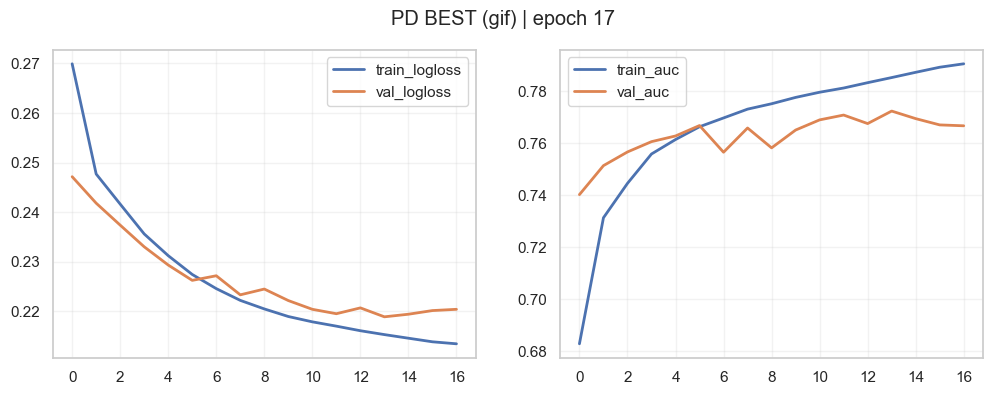

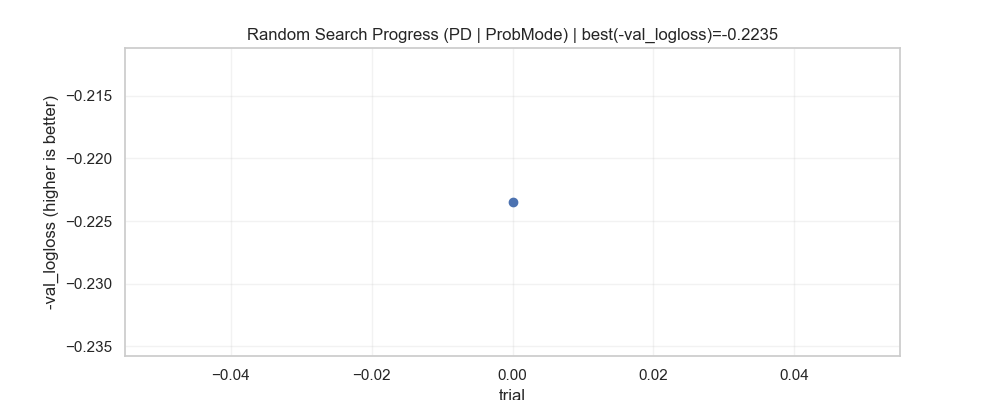

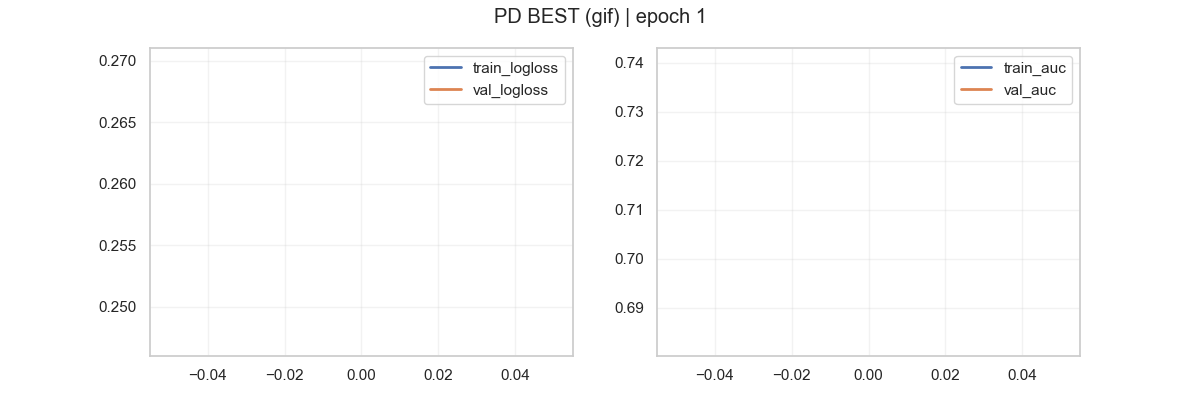


Best PD selection metric:
  best_val_logloss = 0.218878
  best_score (-val_logloss) = -0.218878
Best PD hparams: {'activation': 'tanh', 'L': 4, 'hidden_units': 512, 'batch_size': 256, 'keep_prob': 0.9, 'l2_lambda': 1.543846841972349e-05, 'alpha0': 0.00023331237132320486, 'decay_rate': 0.00018314451871562787, 'bn_momentum': 0.99}

[PD Binary NN | ProbMode] Core Metrics (Probability + Binary)
VAL AUC=0.7727
TEST AUC=0.7768 | Gini=0.5536 | PR-AUC(AP)=0.1927 | LogLoss=0.2124 | Brier=0.0575 | ECE=0.0060

Threshold policy: ks | chosen threshold t*=0.0639
Outputs:
  pd_prob_test  -> probability P(default|x) in [0,1]
  default_pred_test -> 0/1 decision: 1[pd_prob_test >= t*]


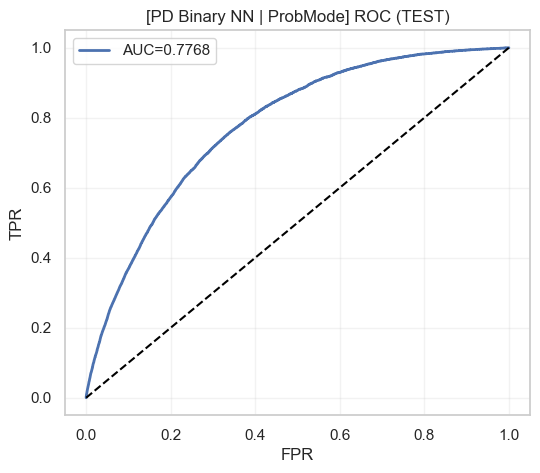

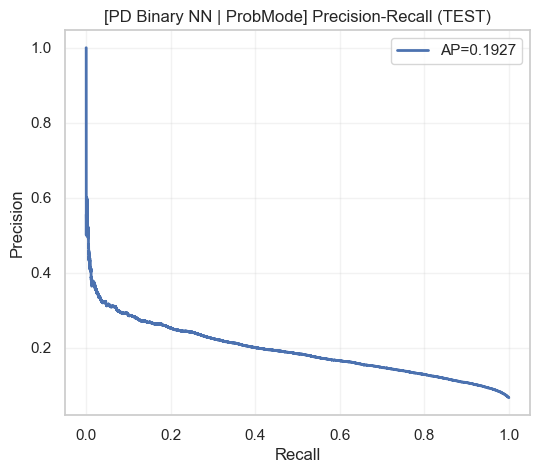

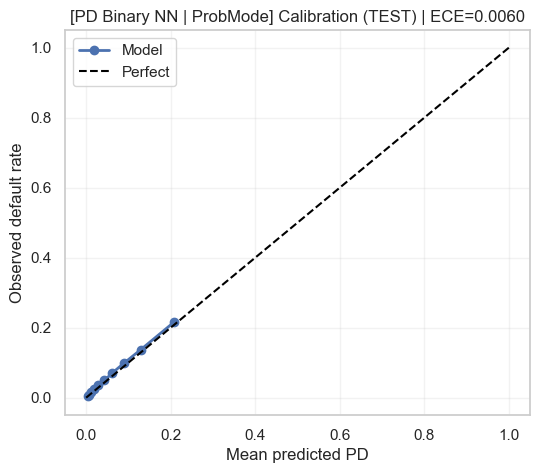

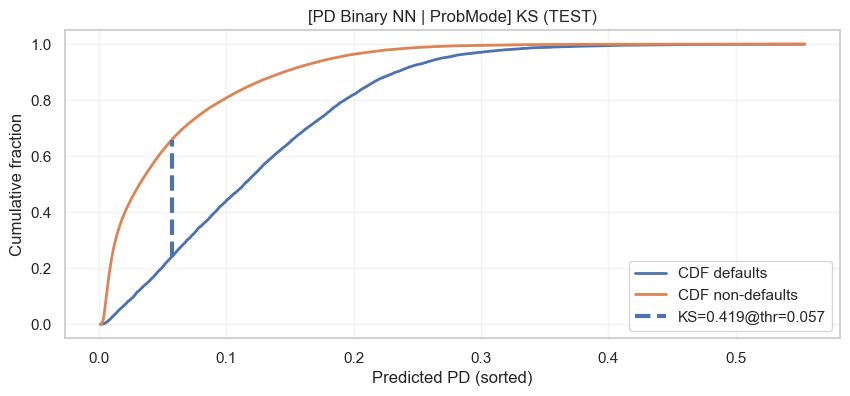

KS(TEST)=0.4186 at thr=0.0573


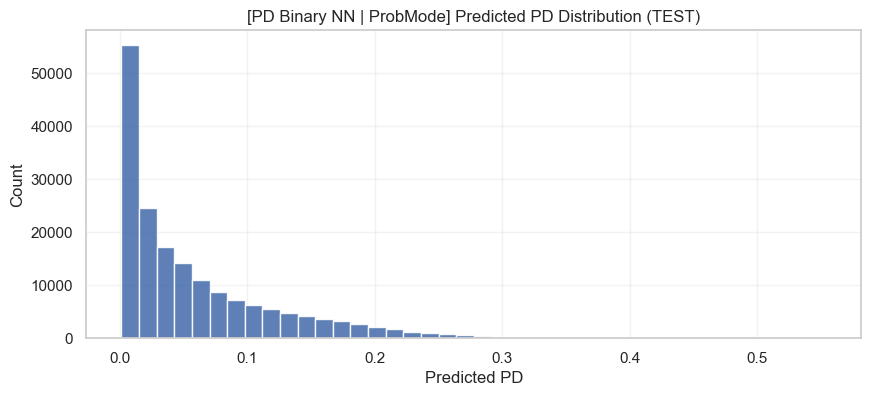

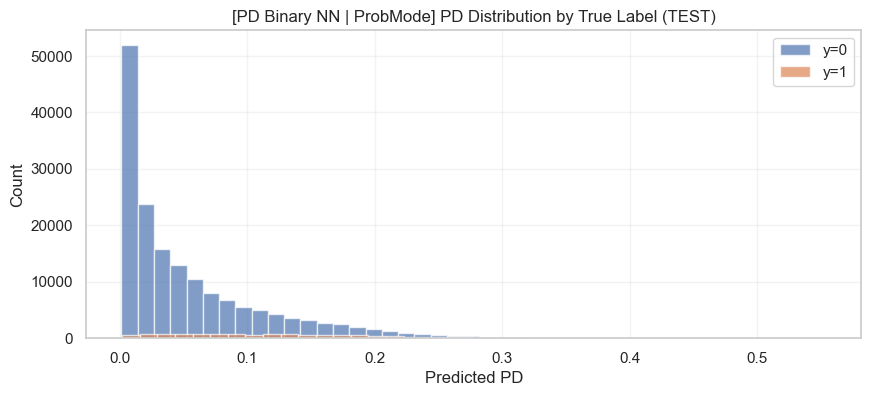


[PD Binary NN | ProbMode] TEST Report (threshold t* = 0.0639 from VAL policy 'ks')
              precision    recall  f1-score   support

           0     0.9726    0.6895    0.8070    165606
           1     0.1424    0.7267    0.2381     11747

    accuracy                         0.6920    177353
   macro avg     0.5575    0.7081    0.5225    177353
weighted avg     0.9177    0.6920    0.7693    177353



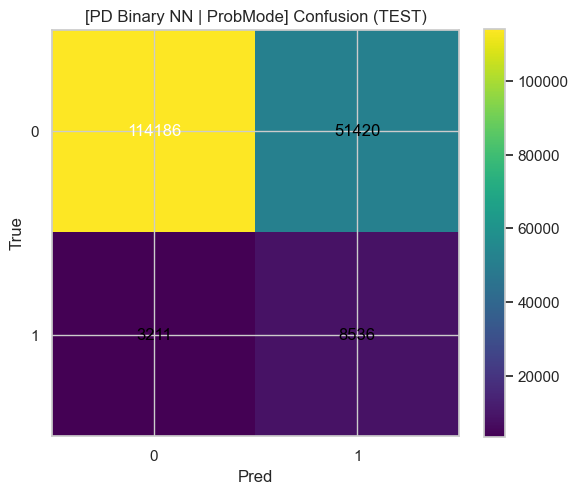

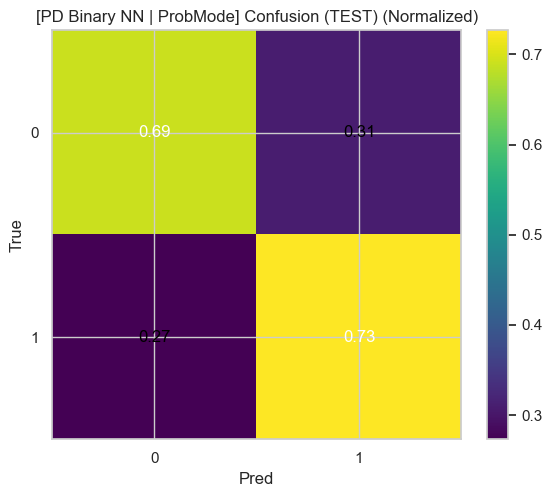


[PD Binary NN | ProbMode] Decile Report (TEST)
Decile    Count     Avg_PD    BadRate     Lift
     1    17736     0.0046     0.0048     0.07
     2    17735     0.0076     0.0079     0.12
     3    17735     0.0115     0.0151     0.23
     4    17736     0.0181     0.0258     0.39
     5    17735     0.0289     0.0374     0.57
     6    17735     0.0432     0.0495     0.75
     7    17736     0.0617     0.0704     1.06
     8    17735     0.0887     0.0979     1.48
     9    17735     0.1290     0.1369     2.07
    10    17735     0.2087     0.2167     3.27


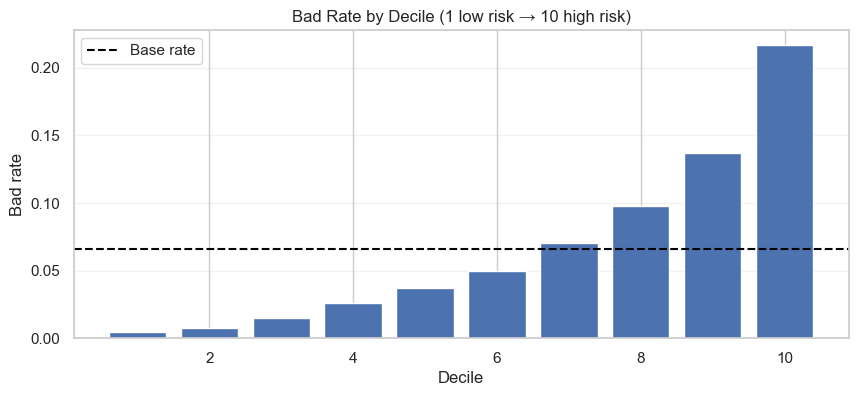

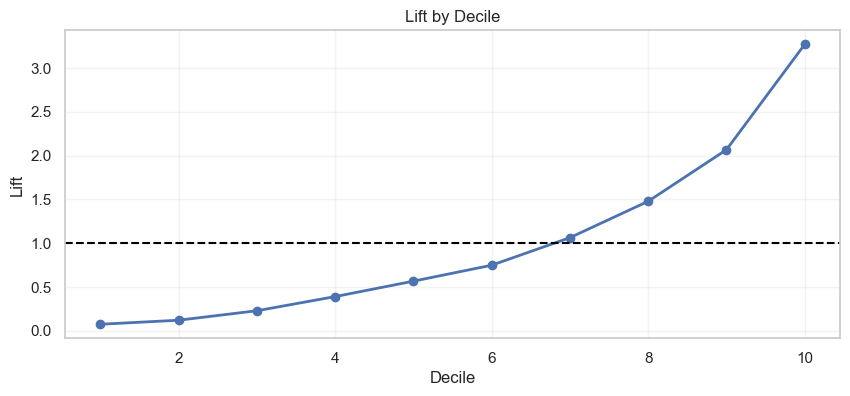

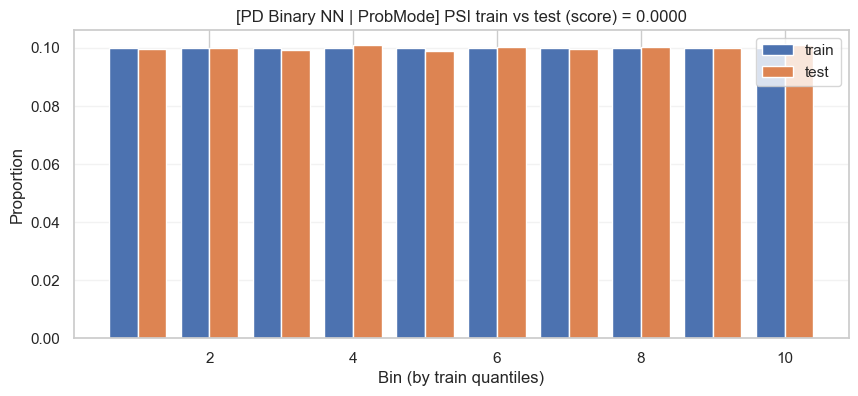

PSI(train vs test)=0.0000  (<0.10 stable, 0.10~0.25 watch, >0.25 drift)


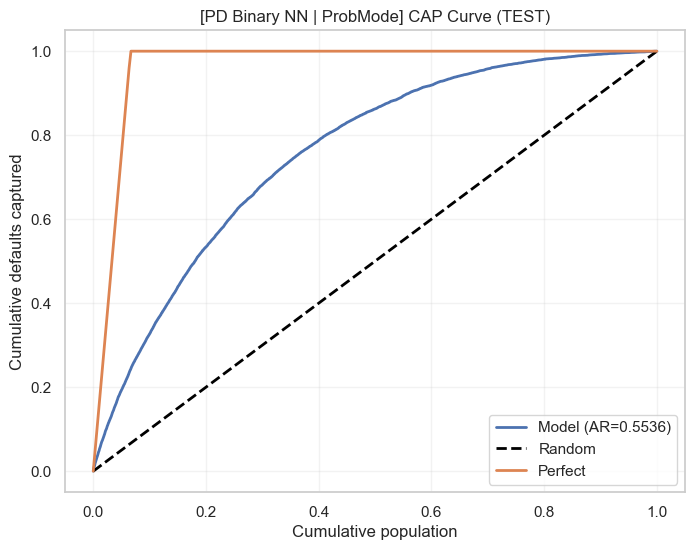

CAP Accuracy Ratio (AR) = 0.5536

[PD Binary NN | ProbMode] Top-K Default Capture (TEST)
  Top%      Pop  CapturedBad  CaptureRate BadRate_in_Top%
     1     1774          559       0.0476          0.3151
     5     8868         2267       0.1930          0.2556
    10    17735         3843       0.3271          0.2167
    20    35471         6272       0.5339          0.1768

##############################################################################################################
B) Baseline: sklearn LogisticRegression (probability sanity check)
LogReg TEST: AUC=0.7539 | Gini=0.5078 | LogLoss=0.2182 | Brier=0.0585


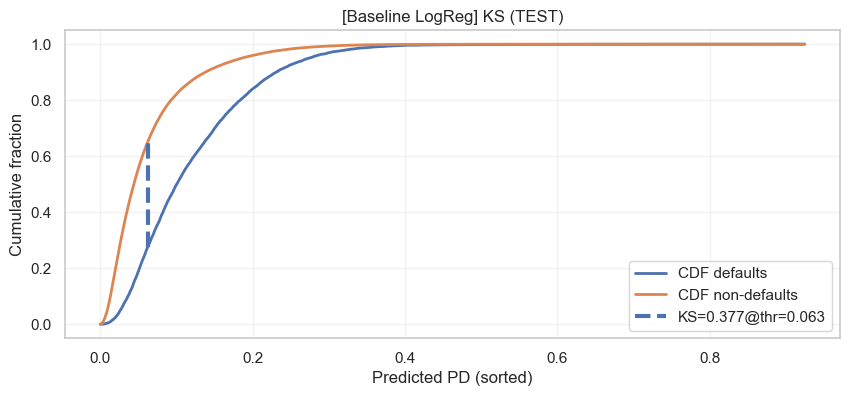

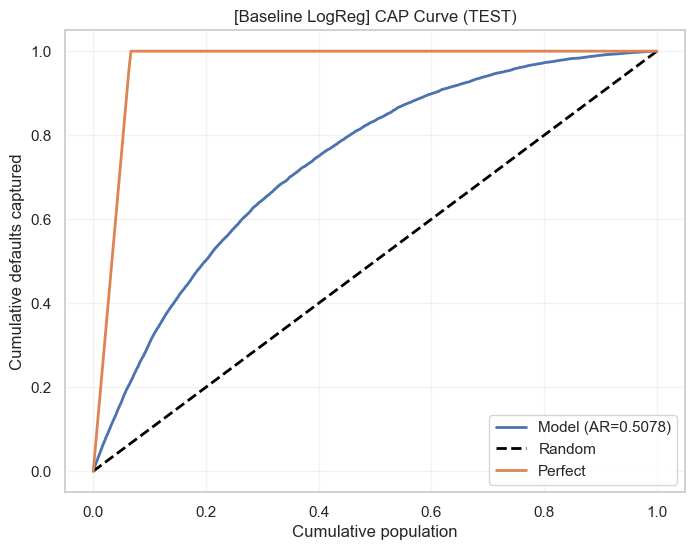


✅ ALL DONE (PD probability + binary decision).


In [ ]:
import io
import math
import random
import time

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import clear_output, display
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

STANDARDIZE_IF_NEEDED = False
DO_GRAD_CHECK = True
GRAD_CHECK_NUM_COORDS = 25
GRAD_CHECK_EPS = 1e-7

N_TRIALS_BINARY = 8
MAX_EPOCHS = 20
EARLY_STOP_PATIENCE = 3

RECORD_SEARCH_GIF = True
RECORD_BEST_TRAIN_GIF = True

RUN_SKLEARN_LOGREG_BASELINE = True

THRESHOLD_MODE = "ks"
FIXED_THRESHOLD = 0.50
TARGET_REJECT_RATE = 0.10
COST_FP = 1.0
COST_FN = 5.0

EPS = 1e-12


def _to_pct_float(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    return pd.to_numeric(s, errors="coerce")


def load_and_engineer_features(csv_path: str) -> tuple[pd.DataFrame, pd.Series]:
    df = pd.read_csv(csv_path)
    df_multi = df.copy()

    features = [
        "loan_amnt",
        "funded_amnt",
        "funded_amnt_inv",
        "term",
        "int_rate",
        "installment",
        "purpose",
        "initial_list_status",
        "issue_d",
        "grade",
        "sub_grade",
        "emp_length",
        "home_ownership",
        "annual_inc",
        "verification_status",
        "addr_state",
        "application_type",
        "dti",
        "delinq_2yrs",
        "earliest_cr_line",
        "inq_last_6mths",
        "open_acc",
        "pub_rec",
        "revol_bal",
        "revol_util",
        "total_acc",
        "collections_12_mths_ex_med",
        "acc_now_delinq",
        "tot_coll_amt",
        "tot_cur_bal",
        "total_rev_hi_lim",
        "mths_since_last_delinq",
        "mths_since_last_record",
        "mths_since_last_major_derog",
    ]

    X = df_multi.loc[:, features].copy()

    if "int_rate" in X.columns:
        X["int_rate"] = _to_pct_float(X["int_rate"])
    if "revol_util" in X.columns:
        X["revol_util"] = _to_pct_float(X["revol_util"])

    X["ever_delinq"] = X["mths_since_last_delinq"].notna().astype(int)
    X["ever_major_derog"] = X["mths_since_last_major_derog"].notna().astype(int)
    X["ever_public_record"] = X["mths_since_last_record"].notna().astype(int)

    X["mths_since_last_delinq"] = X["mths_since_last_delinq"].fillna(999)
    X["mths_since_last_major_derog"] = X["mths_since_last_major_derog"].fillna(999)
    X["mths_since_last_record"] = X["mths_since_last_record"].fillna(999)

    X["delinq_24m"] = ((X["mths_since_last_delinq"] <= 24) & (X["ever_delinq"] == 1)).astype(int)
    X["derog_60m"] = ((X["mths_since_last_major_derog"] <= 60) & (X["ever_major_derog"] == 1)).astype(int)
    X["record_60m"] = ((X["mths_since_last_record"] <= 60) & (X["ever_public_record"] == 1)).astype(int)

    X["delinq_recency_score"] = X["ever_delinq"] * (1.0 / (1.0 + X["mths_since_last_delinq"]))
    X["derog_recency_score"] = X["ever_major_derog"] * (1.0 / (1.0 + X["mths_since_last_major_derog"]))
    X["record_recency_score"] = X["ever_public_record"] * (1.0 / (1.0 + X["mths_since_last_record"]))

    drop_small_na = [
        "delinq_2yrs",
        "inq_last_6mths",
        "open_acc",
        "pub_rec",
        "total_acc",
        "collections_12_mths_ex_med",
        "acc_now_delinq",
        "revol_util",
        "issue_d",
        "earliest_cr_line",
    ]
    X = X.dropna(subset=[c for c in drop_small_na if c in X.columns]).copy()

    cols_zero = [
        "delinq_2yrs",
        "inq_last_6mths",
        "open_acc",
        "pub_rec",
        "total_acc",
        "collections_12_mths_ex_med",
        "acc_now_delinq",
    ]
    for c in cols_zero:
        if c in X.columns:
            X[c] = X[c].fillna(0)

    if "revol_util" in X.columns:
        X["revol_util"] = X["revol_util"].fillna(X["revol_util"].median())

    if "emp_length" in X.columns:
        X["emp_length"] = X["emp_length"].fillna("0")

    cols_balance = ["tot_coll_amt", "tot_cur_bal", "total_rev_hi_lim"]
    for c in cols_balance:
        if c in X.columns:
            X[c] = X[c].fillna(0)

    issue_dt = pd.to_datetime(X["issue_d"], errors="coerce")
    ecl_dt = pd.to_datetime(X["earliest_cr_line"], errors="coerce")
    bad_date = issue_dt.isna() | ecl_dt.isna()

    if bad_date.any():
        keep_idx = X.index[~bad_date]
        X = X.loc[keep_idx].copy()
        issue_dt = issue_dt.loc[keep_idx]
        ecl_dt = ecl_dt.loc[keep_idx]

    X["credit_age"] = (issue_dt.dt.year - ecl_dt.dt.year).clip(lower=0)
    X["credit_age"] = X["credit_age"].fillna(X["credit_age"].median())

    default_classes = [
        "Charged Off",
        "Default",
        "Late (31-120 days)",
        "Does not meet the credit policy. Status:Charged Off",
    ]
    y_bin = df_multi["loan_status"].isin(default_classes).astype(int).loc[X.index]

    return X, y_bin


def plot_label_distribution(y_bin: pd.Series) -> None:
    sns.set(style="whitegrid")
    bin_counts = y_bin.value_counts().sort_index()

    plt.figure(figsize=(6, 4))
    sns.barplot(x=bin_counts.index, y=bin_counts.values, palette=["#2ECC71", "#E74C3C"])
    plt.title("Binary Label Distribution", fontsize=14, weight="bold")
    plt.xlabel("Class (0 = Non-default, 1 = Default)")
    plt.ylabel("Count")
    for i, v in enumerate(bin_counts.values):
        plt.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
    plt.tight_layout()
    plt.show()


def split_data(X: pd.DataFrame, y_bin: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    X_trainval, X_test, yb_trainval, yb_test = train_test_split(
        X, y_bin, test_size=0.20, random_state=SEED, shuffle=True, stratify=y_bin
    )
    X_train, X_val, yb_train, yb_val = train_test_split(
        X_trainval, yb_trainval, test_size=0.25, random_state=SEED, shuffle=True, stratify=yb_trainval
    )
    return X_train, X_val, X_test, yb_train, yb_val, yb_test


def preprocess_splits(
    X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    orig_cols_train = X_train.columns.tolist()
    orig_cols_val = X_val.columns.tolist()
    orig_cols_test = X_test.columns.tolist()

    amount_keep = "funded_amnt_inv"
    amount_group = ["loan_amnt", "funded_amnt", "funded_amnt_inv"]
    drop_amount = [c for c in amount_group if c in X_train.columns and c != amount_keep]

    for _df in (X_train, X_val, X_test):
        _df.drop(columns=drop_amount, inplace=True, errors="ignore")

    drop_mths_since = [
        "mths_since_last_delinq",
        "mths_since_last_record",
        "mths_since_last_major_derog",
    ]
    drop_mths_since = [c for c in drop_mths_since if c in X_train.columns]

    for _df in (X_train, X_val, X_test):
        _df.drop(columns=drop_mths_since, inplace=True, errors="ignore")

    drop_raw_obj = [c for c in ["term", "emp_length", "issue_d", "earliest_cr_line"] if c in X_train.columns]
    for _df in (X_train, X_val, X_test):
        _df.drop(columns=drop_raw_obj, inplace=True, errors="ignore")

    dropped_raw_obj_cols = drop_raw_obj[:]
    dropped_amount_cols = drop_amount[:]
    dropped_mths_cols = drop_mths_since[:]

    binary_like = {
        "ever_delinq",
        "ever_major_derog",
        "ever_public_record",
        "delinq_24m",
        "derog_60m",
        "record_60m",
    }

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cont_cols = []
    for c in num_cols:
        if c in binary_like:
            continue
        uniq = X_train[c].dropna().unique()
        if (len(uniq) <= 2) and set(uniq).issubset({0, 1}):
            continue
        cont_cols.append(c)

    lower_q, upper_q = 0.001, 0.999
    if cont_cols:
        q_low = X_train[cont_cols].quantile(lower_q)
        q_high = X_train[cont_cols].quantile(upper_q)
        X_train[cont_cols] = X_train[cont_cols].clip(lower=q_low, upper=q_high, axis=1)
        X_val[cont_cols] = X_val[cont_cols].clip(lower=q_low, upper=q_high, axis=1)
        X_test[cont_cols] = X_test[cont_cols].clip(lower=q_low, upper=q_high, axis=1)
    else:
        q_low = pd.Series(dtype=float)
        q_high = pd.Series(dtype=float)

    if cont_cols:
        scaler = StandardScaler()
        X_train[cont_cols] = scaler.fit_transform(X_train[cont_cols])
        train_mu = pd.Series(scaler.mean_, index=cont_cols, name="mu")
        train_sd = pd.Series(scaler.scale_, index=cont_cols, name="sd")
        X_val[cont_cols] = scaler.transform(X_val[cont_cols])
        X_test[cont_cols] = scaler.transform(X_test[cont_cols])
    else:
        scaler = None
        train_mu = pd.Series(dtype=float, name="mu")
        train_sd = pd.Series(dtype=float, name="sd")

    standardized_cols = cont_cols[:]

    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=None)

    Xtr_cat = ohe.fit_transform(X_train[cat_cols]) if cat_cols else np.empty((len(X_train), 0))
    Xva_cat = ohe.transform(X_val[cat_cols]) if cat_cols else np.empty((len(X_val), 0))
    Xte_cat = ohe.transform(X_test[cat_cols]) if cat_cols else np.empty((len(X_test), 0))

    ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if cat_cols else []

    Xtr_cat = pd.DataFrame(Xtr_cat, index=X_train.index, columns=ohe_cols)
    Xva_cat = pd.DataFrame(Xva_cat, index=X_val.index, columns=ohe_cols)
    Xte_cat = pd.DataFrame(Xte_cat, index=X_test.index, columns=ohe_cols)

    Xtr_num = X_train.drop(columns=cat_cols, errors="ignore")
    Xva_num = X_val.drop(columns=cat_cols, errors="ignore")
    Xte_num = X_test.drop(columns=cat_cols, errors="ignore")

    X_train = pd.concat([Xtr_num, Xtr_cat], axis=1)
    X_val = pd.concat([Xva_num, Xva_cat], axis=1)
    X_test = pd.concat([Xte_num, Xte_cat], axis=1)

    new_ohe_cols = ohe_cols[:]

    bad_obj = X_train.columns[X_train.dtypes == "object"].tolist()
    assert not bad_obj, f"Object columns remain after OHE: {bad_obj[:10]}"

    freq_thr = 0.9995
    top_freq = X_train.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
    near_const_cols = top_freq[top_freq >= freq_thr].index.tolist()

    if near_const_cols:
        X_train = X_train.drop(columns=near_const_cols, errors="ignore")
        X_val = X_val.drop(columns=near_const_cols, errors="ignore")
        X_test = X_test.drop(columns=near_const_cols, errors="ignore")

    print(f"Near-constant columns removed (>= {freq_thr}): {len(near_const_cols)}")
    assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), "Column mismatch across splits!"

    cont_cols_after = [c for c in standardized_cols if c in X_train.columns]
    if len(cont_cols_after) > 1:
        corr_cont = X_train[cont_cols_after].corr()
        plt.figure(figsize=(14, 10))
        mask = np.triu(np.ones_like(corr_cont, dtype=bool))
        sns.heatmap(
            corr_cont, mask=mask, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.8}
        )
        plt.title("Correlation Heatmap (Train Only) - Continuous(Standardized)")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough continuous columns for correlation heatmap.")

    corr_all = X_train.corr(numeric_only=True)
    thr = 0.75
    pairs = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
    high_pairs = pairs[pairs.abs() >= thr]
    print(f"High-correlation pairs (|corr| >= {thr}):")
    print(high_pairs.head(50))

    final_cols_train = X_train.columns.tolist()
    removed_cols = sorted(list(set(orig_cols_train) - set(final_cols_train)))
    added_cols = sorted(list(set(final_cols_train) - set(orig_cols_train)))

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)

    print("\n" + "=" * 100)
    print("ORIGINAL X_train.columns:")
    print(pd.Index(orig_cols_train))

    print("\n" + "=" * 100)
    print("STANDARDIZED columns:")
    print(pd.Index(standardized_cols))

    print("\n" + "=" * 100)
    print("DROPPED raw object/date columns:")
    print(pd.Index(dropped_raw_obj_cols))

    print("\n" + "=" * 100)
    print("DROPPED redundant amount cols:")
    print(pd.Index(dropped_amount_cols))
    print(f"Kept amount column: {amount_keep}")

    print("\n" + "=" * 100)
    print("DROPPED raw mths_since_last_* cols:")
    print(pd.Index(dropped_mths_cols))

    print("\n" + "=" * 100)
    print("ONE-HOT encoded categorical columns:")
    print(pd.Index(cat_cols))

    print("\n" + "=" * 100)
    print("NEW columns added by OHE:")
    print(pd.Index(new_ohe_cols))

    print("\n" + "=" * 100)
    print("NEAR-CONSTANT columns removed:")
    print(pd.Index(near_const_cols))

    print("\n" + "=" * 100)
    print("REMOVED columns overall (orig - final):")
    print(pd.Index(removed_cols))

    print("\n" + "=" * 100)
    print("ADDED columns overall (final - orig):")
    print(pd.Index(added_cols))

    print("\n" + "=" * 100)
    print("FINAL X_train.columns:")
    print(pd.Index(final_cols_train))

    print("\nFinal shapes:")
    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)
    print("X_test :", X_test.shape)

    print("\nSaved scaling stats (TRAIN):")
    print("train_mu head:\n", train_mu.head())
    print("train_sd head:\n", train_sd.head())

    std_check_cols = [c for c in standardized_cols if c in X_train.columns]
    if std_check_cols:
        mu_check = X_train[std_check_cols].mean().abs().sort_values(ascending=False).head(10)
        sd_check = (X_train[std_check_cols].std(ddof=0) - 1).abs().sort_values(ascending=False).head(10)
        print("\n" + "=" * 100)
        print("SANITY (TRAIN) standardized cols:")
        print("Top 10 |mean|:")
        print(mu_check)
        print("\nTop 10 |std-1|:")
        print(sd_check)

    return X_train, X_val, X_test


def count01(y, name: str) -> None:
    y = np.asarray(y).astype(int)
    u, c = np.unique(y, return_counts=True)
    print(name, dict(zip(u, c)), "pos_rate=", float(y.mean()))


def run_logistic_regression_module(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame, yb_train, yb_val, yb_test):
    assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), "Column mismatch!"
    for name, X_ in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
        na = int(X_.isna().sum().sum())
        assert na == 0, f"{name} has NaNs: {na}"

    def _count01(y, name):
        y = np.asarray(y).astype(int)
        u, c = np.unique(y, return_counts=True)
        print(f"{name}: {dict(zip(u,c))} | pos_rate={y.mean():.6f}")

    _count01(yb_train, "yb_train")
    _count01(yb_val, "yb_val")
    _count01(yb_test, "yb_test")

    C_grid = np.logspace(-3, 3, 13)
    best = {"C": None, "val_logloss": np.inf, "val_auc": -np.inf, "model": None}

    for C in C_grid:
        model = LogisticRegression(
            penalty="l2",
            C=float(C),
            solver="lbfgs",
            max_iter=4000,
            class_weight=None,
            random_state=SEED,
        )
        model.fit(X_train, yb_train)

        p_val = model.predict_proba(X_val)[:, 1]
        ll = log_loss(yb_val, p_val)
        auc = roc_auc_score(yb_val, p_val)

        if ll < best["val_logloss"]:
            best = {"C": float(C), "val_logloss": float(ll), "val_auc": float(auc), "model": model}

    clf = best["model"]
    print("\n" + "=" * 100)
    print(
        f"Selected C by min VAL LogLoss: C={best['C']:.6g} | val_logloss={best['val_logloss']:.6f} | val_auc={best['val_auc']:.6f}"
    )

    p_train = clf.predict_proba(X_train)[:, 1]
    p_val = clf.predict_proba(X_val)[:, 1]
    p_test = clf.predict_proba(X_test)[:, 1]

    fpr_v, tpr_v, ths_v = roc_curve(yb_val, p_val)
    ks_v = tpr_v - fpr_v
    k = int(np.argmax(ks_v))
    threshold = float(ths_v[k])

    print("\n" + "=" * 100)
    print(
        f"Selected threshold by max VAL KS: th={threshold:.6f} | KS={float(ks_v[k]):.6f} | TPR={float(tpr_v[k]):.6f} | FPR={float(fpr_v[k]):.6f}"
    )

    def _metrics(y_true, p, th, name):
        y_true = np.asarray(y_true).astype(int)
        yhat = (p >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()

        fpr, tpr, _ = roc_curve(y_true, p)
        ks = float(np.max(tpr - fpr))

        out = {
            "set": name,
            "n": int(len(y_true)),
            "pos_rate": float(y_true.mean()),
            "AUC": float(roc_auc_score(y_true, p)) if len(np.unique(y_true)) == 2 else np.nan,
            "AP": float(average_precision_score(y_true, p)) if len(np.unique(y_true)) == 2 else np.nan,
            "LogLoss": float(log_loss(y_true, p)),
            "Brier": float(brier_score_loss(y_true, p)),
            "KS": ks,
            "TP": int(tp),
            "FP": int(fp),
            "TN": int(tn),
            "FN": int(fn),
            "Accuracy": float((tp + tn) / (tp + tn + fp + fn + 1e-12)),
            "Precision": float(tp / (tp + fp + 1e-12)),
            "Recall": float(tp / (tp + fn + 1e-12)),
            "F1": float((2 * tp) / (2 * tp + fp + fn + 1e-12)),
        }
        return out, yhat

    m_train, yhat_train = _metrics(yb_train, p_train, threshold, "train")
    m_val, yhat_val = _metrics(yb_val, p_val, threshold, "val")
    m_test, yhat_test = _metrics(yb_test, p_test, threshold, "test")

    metrics_df = pd.DataFrame([m_train, m_val, m_test])
    pd.set_option("display.width", 220)
    pd.set_option("display.max_columns", None)

    print("\n" + "=" * 100)
    print("Summary metrics (threshold = VAL KS-optimal)")
    print(metrics_df)

    print("\n" + "=" * 100)
    print("Classification report (TEST)")
    print(classification_report(yb_test, yhat_test, digits=4))

    print("\n" + "=" * 100)
    print("Confusion matrix (TEST) [[TN FP],[FN TP]]")
    print(confusion_matrix(yb_test, yhat_test, labels=[0, 1]))

    fpr_t, tpr_t, _ = roc_curve(yb_test, p_test)
    auc_t = roc_auc_score(yb_test, p_test)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_t, tpr_t, label=f"AUC={auc_t:.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC (Test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec_t, rec_t, _ = precision_recall_curve(yb_test, p_test)
    ap_t = average_precision_score(yb_test, p_test)
    plt.figure(figsize=(6, 5))
    plt.plot(rec_t, prec_t, label=f"AP={ap_t:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall (Test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(fpr_t, tpr_t - fpr_t, label="KS gap (TPR-FPR)")
    plt.axhline(np.max(tpr_t - fpr_t), linestyle="--", label=f"KS={np.max(tpr_t-fpr_t):.4f}")
    plt.xlabel("FPR (as you sweep threshold)")
    plt.ylabel("TPR - FPR")
    plt.title("KS Curve (Test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    def decile_table(y_true, p, n_bins=10):
        y_true = np.asarray(y_true).astype(int)
        df_ = pd.DataFrame({"y": y_true, "p": p})
        df_ = df_.sort_values("p", ascending=False).reset_index(drop=True)
        df_["bin"] = pd.qcut(df_.index + 1, q=n_bins, labels=False) + 1

        base = df_["y"].mean()
        tab = (
            df_.groupby("bin")
            .agg(n=("y", "size"), bads=("y", "sum"), bad_rate=("y", "mean"), p_mean=("p", "mean"))
            .reset_index()
        )

        tab["lift"] = tab["bad_rate"] / (base + 1e-12)
        tab["cum_n"] = tab["n"].cumsum()
        tab["cum_bads"] = tab["bads"].cumsum()
        tab["cum_bad_rate"] = tab["cum_bads"] / (tab["cum_n"] + 1e-12)
        tab["cum_capture"] = tab["cum_bads"] / (df_["y"].sum() + 1e-12)

        return tab, base

    tab_test, base_test = decile_table(yb_test, p_test, n_bins=10)

    print("\n" + "=" * 100)
    print(
        f"Decile / Lift (TEST) | base_bad_rate={base_test:.6f} | higher bin=lower risk? Here bin=1 is the highest risk(highest p)"
    )
    print(tab_test)

    plt.figure(figsize=(7, 4))
    plt.plot(tab_test["bin"], tab_test["cum_capture"], marker="o")
    plt.xlabel("Decile (1=highest risk)")
    plt.ylabel("Cumulative bad capture")
    plt.title("Cumulative Bad Capture (Test)")
    plt.tight_layout()
    plt.show()

    return {"clf": clf, "threshold": threshold, "p_test": p_test, "yhat_test": yhat_test}


def to_np_float32(X):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        X = X.values
    return np.asarray(X, dtype=np.float32)


def to_np(y):
    if isinstance(y, (pd.DataFrame, pd.Series)):
        y = y.values
    return np.asarray(y)


def shuffle_in_unison(X, y, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]


def standardize_train_only(Xtr, Xva, Xte, eps=1e-12):
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0) + eps
    return (Xtr - mu) / sd, (Xva - mu) / sd, (Xte - mu) / sd, mu, sd


def class_balance_report(y, name):
    y = np.asarray(y).astype(int)
    p = y.mean() if len(y) else np.nan
    print(f"{name}: n={len(y)} | default_rate={p:.6f} | #1={(y==1).sum()} #0={(y==0).sum()} | unique={np.unique(y)}")


def make_ds(X, y, batch_size, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=min(len(X), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


class EpochInverseDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, alpha0, decay_rate, steps_per_epoch):
        super().__init__()
        self.alpha0 = tf.constant(alpha0, dtype=tf.float32)
        self.decay_rate = tf.constant(decay_rate, dtype=tf.float32)
        self.steps_per_epoch = tf.constant(float(steps_per_epoch), dtype=tf.float32)

    def __call__(self, step):
        epoch = tf.cast(step, tf.float32) / self.steps_per_epoch
        return self.alpha0 / (1.0 + self.decay_rate * epoch)


def build_mlp(nx, L, hidden_units, activation, l2_lambda, keep_prob, bn_momentum):
    tf.keras.backend.clear_session()

    if activation == "relu":
        init = tf.keras.initializers.HeNormal(seed=SEED)
    elif activation == "tanh":
        init = tf.keras.initializers.GlorotUniform(seed=SEED)
    else:
        raise ValueError("activation must be relu or tanh")

    reg = tf.keras.regularizers.l2(l2_lambda)

    x_in = keras.Input(shape=(nx,), name="X")
    x = x_in

    for l in range(1, L + 1):
        x = layers.Dense(
            hidden_units,
            activation=None,
            kernel_initializer=init,
            kernel_regularizer=reg,
            name=f"Dense{l}",
        )(x)
        x = layers.BatchNormalization(momentum=bn_momentum, name=f"BN{l}")(x)
        x = layers.Activation(activation, name=f"{activation}{l}")(x)
        if keep_prob < 1.0:
            x = layers.Dropout(rate=(1.0 - keep_prob), seed=SEED, name=f"Dropout{l}")(x)

    y_out = layers.Dense(1, activation="sigmoid", kernel_regularizer=reg, name="pd_hat")(x)
    return keras.Model(x_in, y_out)


def total_loss(model, Xb, yb, training_flag):
    ypred = model(Xb, training=training_flag)
    yb = tf.cast(tf.reshape(yb, (-1, 1)), tf.float32)
    base = tf.reduce_mean(tf.keras.losses.binary_crossentropy(yb, ypred))
    if model.losses:
        base = base + tf.add_n(model.losses)
    return base


def pack_theta(model):
    meta, vecs, offset = [], [], 0
    for v in model.trainable_variables:
        a = v.numpy().ravel()
        n = a.size
        vecs.append(a)
        meta.append((v, v.shape, offset, offset + n))
        offset += n
    theta = np.concatenate(vecs).astype(np.float32)
    return theta, meta


def assign_theta(theta, meta):
    for (v, shape, a, b) in meta:
        v.assign(theta[a:b].reshape(shape))


def grad_check_for_trial(model, h, Xb, yb, num_coords=25, eps=1e-7):
    nx = Xb.shape[1]
    gc_model = build_mlp(
        nx=nx,
        L=h["L"],
        hidden_units=h["hidden_units"],
        activation=h["activation"],
        l2_lambda=h["l2_lambda"],
        keep_prob=1.0,
        bn_momentum=h["bn_momentum"],
    )
    gc_model.set_weights(model.get_weights())

    Xb_tf = tf.convert_to_tensor(Xb, tf.float32)
    yb_tf = tf.convert_to_tensor(yb)

    _ = gc_model(Xb_tf, training=True)

    with tf.GradientTape() as tape:
        J = total_loss(gc_model, Xb_tf, yb_tf, training_flag=False)
    grads = tape.gradient(J, gc_model.trainable_variables)
    grad_vec = np.concatenate([g.numpy().ravel() for g in grads]).astype(np.float32)

    theta0, meta = pack_theta(gc_model)
    p = len(theta0)
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(p, size=min(num_coords, p), replace=False)

    approx = np.zeros_like(grad_vec)
    for i in idxs:
        tp = theta0.copy()
        tm = theta0.copy()
        tp[i] += eps
        tm[i] -= eps
        assign_theta(tp, meta)
        Jp = float(total_loss(gc_model, Xb_tf, yb_tf, training_flag=False).numpy())
        assign_theta(tm, meta)
        Jm = float(total_loss(gc_model, Xb_tf, yb_tf, training_flag=False).numpy())
        approx[i] = (Jp - Jm) / (2 * eps)

    assign_theta(theta0, meta)

    num = np.linalg.norm(approx[idxs] - grad_vec[idxs])
    den = np.linalg.norm(approx[idxs]) + np.linalg.norm(grad_vec[idxs]) + 1e-12
    return float(num / den)


class LivePlotter:
    def __init__(self, title, make_gif=False):
        self.title = title
        self.make_gif = make_gif
        self.frames = []
        self.tr_loss, self.va_loss = [], []
        self.tr_metric, self.va_metric = [], []

    def _capture(self, fig):
        fig.canvas.draw()
        w, h = fig.canvas.get_width_height()
        buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
        self.frames.append(buf[:, :, :3].copy())

    def update(self, epoch, logs, metric_name):
        self.tr_loss.append(logs.get("loss", np.nan))
        self.va_loss.append(logs.get("val_loss", np.nan))
        self.tr_metric.append(logs.get(metric_name, np.nan))
        self.va_metric.append(logs.get("val_" + metric_name, np.nan))

        clear_output(wait=True)
        fig = plt.figure(figsize=(12, 4))
        fig.suptitle(f"{self.title} | epoch {epoch}")

        ax1 = plt.subplot(1, 2, 1)
        ax1.plot(self.tr_loss, label="train_logloss", linewidth=2)
        ax1.plot(self.va_loss, label="val_logloss", linewidth=2)
        ax1.grid(True, alpha=0.25)
        ax1.legend()

        ax2 = plt.subplot(1, 2, 2)
        ax2.plot(self.tr_metric, label=f"train_{metric_name}", linewidth=2)
        ax2.plot(self.va_metric, label=f"val_{metric_name}", linewidth=2)
        ax2.grid(True, alpha=0.25)
        ax2.legend()

        display(fig)
        if self.make_gif:
            self._capture(fig)
        plt.close(fig)

    def gif_bytes(self, fps=4):
        if not self.frames:
            return None
        buf = io.BytesIO()
        imageio.mimsave(buf, self.frames, format="GIF", fps=fps)
        buf.seek(0)
        return buf.getvalue()


class SearchProgressGIF:
    def __init__(self, title, make_gif=True):
        self.title = title
        self.make_gif = make_gif
        self.frames = []

    def update(self, scores, best_score):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(scores, marker="o", linewidth=2)
        plt.title(f"{self.title} | best(-val_logloss)={best_score:.4f}")
        plt.xlabel("trial")
        plt.ylabel("-val_logloss (higher is better)")
        plt.grid(True, alpha=0.25)
        display(fig)
        if self.make_gif:
            fig.canvas.draw()
            w, h = fig.canvas.get_width_height()
            buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
            self.frames.append(buf[:, :, :3].copy())
        plt.close(fig)

    def gif_bytes(self, fps=2):
        if not self.frames:
            return None
        buf = io.BytesIO()
        imageio.mimsave(buf, self.frames, format="GIF", fps=fps)
        buf.seek(0)
        return buf.getvalue()


def sample_alpha_log_1e4_to_1():
    r = -4.0 * np.random.rand()
    return float(10.0 ** r)


def log_uniform(exp_lo, exp_hi):
    r = np.random.uniform(exp_lo, exp_hi)
    return float(10.0 ** r)


def sample_hparams():
    activation = str(np.random.choice(["relu", "tanh"]))
    L = int(np.random.choice([0, 1, 2, 3, 4]))
    hidden_units = int(np.random.choice([64, 128, 256, 384, 512]))
    batch_size = int(np.random.choice([64, 128, 256, 512]))
    keep_prob = float(np.random.choice([0.75, 0.8, 0.9, 1.0]))
    l2_lambda = float(log_uniform(-6, -2))
    alpha0 = float(sample_alpha_log_1e4_to_1())
    decay_rate = float(log_uniform(-4, -1))
    bn_momentum = float(np.random.choice([0.90, 0.95, 0.99]))
    return dict(
        activation=activation,
        L=L,
        hidden_units=hidden_units,
        batch_size=batch_size,
        keep_prob=keep_prob,
        l2_lambda=l2_lambda,
        alpha0=alpha0,
        decay_rate=decay_rate,
        bn_momentum=bn_momentum,
    )


def train_one_trial(Xtr, ytr, Xva, yva, trial_id, max_epochs, record_train_gif=False):
    h = sample_hparams()
    nx = Xtr.shape[1]
    t = h["batch_size"]
    L = h["L"]
    m = N_TRIALS_BINARY

    print("\n" + "=" * 110)
    print(f"[PD Binary | ProbMode] Trial {trial_id}/{m} | nx={nx} | batch(t)={t} | layers(L)={L} | act={h['activation']}")
    print("Hyperparams:", h)

    model = build_mlp(nx, h["L"], h["hidden_units"], h["activation"], h["l2_lambda"], h["keep_prob"], h["bn_momentum"])

    steps_per_epoch = math.ceil(len(Xtr) / t)
    lr_schedule = EpochInverseDecay(h["alpha0"], h["decay_rate"], steps_per_epoch)

    opt = keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

    model.compile(
        optimizer=opt,
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryCrossentropy(name="bce")],
    )

    if DO_GRAD_CHECK:
        idx = np.random.choice(len(Xtr), size=min(256, len(Xtr)), replace=False)
        diff = grad_check_for_trial(model, h, Xtr[idx], ytr[idx], num_coords=GRAD_CHECK_NUM_COORDS, eps=GRAD_CHECK_EPS)
        print(f"🔎 Grad-check relative diff = {diff:.3e}  (good ~1e-7..1e-5; >1e-3 suspicious)")

    ds_tr = make_ds(Xtr, ytr, t, training=True)
    ds_va = make_ds(Xva, yva, t, training=False)

    live = LivePlotter(title=f"PD trial {trial_id}", make_gif=record_train_gif)

    best_val_loss = np.inf
    best_w = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        hist = model.fit(ds_tr, validation_data=ds_va, epochs=1, verbose=1, class_weight=None)
        logs = {k: v[0] for k, v in hist.history.items()}
        live.update(epoch, logs, metric_name="auc")

        val_loss = float(logs.get("val_loss", np.nan))
        if np.isfinite(val_loss) and (val_loss < best_val_loss):
            best_val_loss = val_loss
            best_w = model.get_weights()
            bad = 0
        else:
            bad += 1
            if bad >= EARLY_STOP_PATIENCE:
                print(f"⏹️ Early stop: val_logloss not improved for {EARLY_STOP_PATIENCE} epochs.")
                break

    if best_w is not None:
        model.set_weights(best_w)

    score = -best_val_loss if np.isfinite(best_val_loss) else -np.inf
    return model, score, best_val_loss, h, live.gif_bytes(fps=4)


def random_search_pd(Xtr, ytr, Xva, yva, n_trials, max_epochs):
    scores = []
    best = {"score": -np.inf, "val_loss": np.inf, "model": None, "h": None}
    search_gif = SearchProgressGIF(title="Random Search Progress (PD | ProbMode)", make_gif=RECORD_SEARCH_GIF)

    for j in range(1, n_trials + 1):
        model, score, best_val_loss, h, _ = train_one_trial(
            Xtr, ytr, Xva, yva, trial_id=j, max_epochs=max_epochs, record_train_gif=False
        )
        scores.append(score)

        if score > best["score"]:
            best.update(score=score, val_loss=best_val_loss, model=model, h=h)

        clear_output(wait=True)
        search_gif.update(scores, best["score"])
        print(f"✅ Trial {j}/{n_trials} done | val_logloss={best_val_loss:.4f} | best_val_logloss={best['val_loss']:.4f}")
        print("Best hparams so far:", best["h"])

    best_train_gif_bytes = None
    if RECORD_BEST_TRAIN_GIF and best["h"] is not None:
        print("\n🎬 Re-train BEST once to record training GIF (still selecting by val_logloss)...")
        h = best["h"]
        nx = Xtr.shape[1]
        t = h["batch_size"]

        model = build_mlp(nx, h["L"], h["hidden_units"], h["activation"], h["l2_lambda"], h["keep_prob"], h["bn_momentum"])
        steps_per_epoch = math.ceil(len(Xtr) / t)
        lr_schedule = EpochInverseDecay(h["alpha0"], h["decay_rate"], steps_per_epoch)
        opt = keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8)
        model.compile(
            optimizer=opt,
            loss=keras.losses.BinaryCrossentropy(),
            metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryCrossentropy(name="bce")],
        )

        ds_tr = make_ds(Xtr, ytr, t, training=True)
        ds_va = make_ds(Xva, yva, t, training=False)
        live = LivePlotter(title="PD BEST (gif)", make_gif=True)

        best_val_loss = np.inf
        best_w = None
        bad = 0
        for epoch in range(1, max_epochs + 1):
            hist = model.fit(ds_tr, validation_data=ds_va, epochs=1, verbose=1)
            logs = {k: v[0] for k, v in hist.history.items()}
            live.update(epoch, logs, metric_name="auc")

            vl = float(logs.get("val_loss", np.nan))
            if np.isfinite(vl) and (vl < best_val_loss):
                best_val_loss = vl
                best_w = model.get_weights()
                bad = 0
            else:
                bad += 1
                if bad >= EARLY_STOP_PATIENCE:
                    break

        if best_w is not None:
            model.set_weights(best_w)

        best["model"] = model
        best["val_loss"] = best_val_loss
        best["score"] = -best_val_loss if np.isfinite(best_val_loss) else -np.inf
        best_train_gif_bytes = live.gif_bytes(fps=4)

    return best, search_gif.gif_bytes(fps=2), best_train_gif_bytes


def safe_auc(y_true, p):
    y_true = np.asarray(y_true).astype(int)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, p))


def safe_logloss(y_true, p):
    y_true = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(p), 1e-12, 1 - 1e-12)
    return float(log_loss(y_true, p, labels=[0, 1]))


def expected_calibration_error(y_true, p, n_bins=10, strategy="quantile"):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)

    if strategy == "quantile":
        qs = np.quantile(p, np.linspace(0, 1, n_bins + 1))
        qs[0] = -np.inf
        qs[-1] = np.inf
        bins = qs
    else:
        bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    n = len(p)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        idx = (p > lo) & (p <= hi)
        if idx.sum() == 0:
            continue
        conf = p[idx].mean()
        acc = y_true[idx].mean()
        ece += (idx.sum() / n) * abs(acc - conf)
    return float(ece)


def plot_cm(cm, labels, title="Confusion", normalize=False):
    cm_plot = cm.astype(float)
    if normalize:
        cm_plot = cm_plot / (cm_plot.sum(axis=1, keepdims=True) + 1e-12)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_plot, cmap="viridis")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.colorbar()
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            val = cm_plot[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(val)}"
            plt.text(j, i, txt, ha="center", va="center", color="white" if val > cm_plot.max() * 0.5 else "black")
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def ks_stat(y_true, p):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    if np.unique(y_true).size < 2:
        return np.nan, np.nan
    idx = np.argsort(p)
    y = y_true[idx]
    p_sorted = p[idx]
    n1 = (y == 1).sum()
    n0 = (y == 0).sum()
    if n1 == 0 or n0 == 0:
        return np.nan, np.nan
    cdf1 = np.cumsum(y == 1) / (n1 + 1e-12)
    cdf0 = np.cumsum(y == 0) / (n0 + 1e-12)
    diff = np.abs(cdf1 - cdf0)
    k = int(np.argmax(diff))
    return float(np.max(diff)), float(p_sorted[k])


def ks_plot(y_true, p, title="KS Curve"):
    ks, thr = ks_stat(y_true, p)
    if np.isnan(ks):
        print("⚠️ KS undefined (one-class).")
        return np.nan, np.nan

    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    idx = np.argsort(p)
    y = y_true[idx]
    p_sorted = p[idx]
    n1 = (y == 1).sum()
    n0 = (y == 0).sum()

    cdf1 = np.cumsum(y == 1) / (n1 + 1e-12)
    cdf0 = np.cumsum(y == 0) / (n0 + 1e-12)
    diff = np.abs(cdf1 - cdf0)
    k = int(np.argmax(diff))

    plt.figure(figsize=(10, 4))
    plt.plot(p_sorted, cdf1, linewidth=2, label="CDF defaults")
    plt.plot(p_sorted, cdf0, linewidth=2, label="CDF non-defaults")
    plt.vlines(thr, min(cdf1[k], cdf0[k]), max(cdf1[k], cdf0[k]), linestyles="--", linewidth=3, label=f"KS={ks:.3f}@thr={thr:.3f}")
    plt.title(title)
    plt.xlabel("Predicted PD (sorted)")
    plt.ylabel("Cumulative fraction")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()
    return ks, thr


def decile_report(y_true, p, n_bins=10, title="[PD] Decile"):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    order = np.argsort(p)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(len(p))
    bin_id = np.minimum((ranks * n_bins) // len(p), n_bins - 1)

    base = y_true.mean() + 1e-12
    rows = []
    for b in range(n_bins):
        idx = bin_id == b
        cnt = int(idx.sum())
        avg_pd = float(p[idx].mean()) if cnt else np.nan
        bad = float(y_true[idx].mean()) if cnt else np.nan
        lift = bad / base if cnt else np.nan
        rows.append((b + 1, cnt, avg_pd, bad, lift))

    print("\n" + title)
    print(f"{'Decile':>6} {'Count':>8} {'Avg_PD':>10} {'BadRate':>10} {'Lift':>8}")
    for d, c, ap, br, lf in rows:
        print(f"{d:6d} {c:8d} {ap:10.4f} {br:10.4f} {lf:8.2f}")

    dec = np.array([r[0] for r in rows])
    badr = np.array([r[3] for r in rows])
    lift = np.array([r[4] for r in rows])

    plt.figure(figsize=(10, 4))
    plt.bar(dec, badr)
    plt.axhline(base, linestyle="--", color="black", label="Base rate")
    plt.title("Bad Rate by Decile (1 low risk → 10 high risk)")
    plt.xlabel("Decile")
    plt.ylabel("Bad rate")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(dec, lift, marker="o", linewidth=2)
    plt.axhline(1.0, linestyle="--", color="black")
    plt.title("Lift by Decile")
    plt.xlabel("Decile")
    plt.ylabel("Lift")
    plt.grid(True, alpha=0.25)
    plt.show()


def psi_score(train_scores, test_scores, n_bins=10, title="PSI (train vs test)"):
    train_scores = np.asarray(train_scores)
    test_scores = np.asarray(test_scores)

    qs = np.quantile(train_scores, np.linspace(0, 1, n_bins + 1))
    qs[0] = -np.inf
    qs[-1] = np.inf

    def bin_prop(x):
        props = []
        for i in range(n_bins):
            lo, hi = qs[i], qs[i + 1]
            props.append(((x > lo) & (x <= hi)).mean())
        return np.array(props)

    p = bin_prop(train_scores) + 1e-12
    q = bin_prop(test_scores) + 1e-12
    psi = float(np.sum((p - q) * np.log(p / q)))

    plt.figure(figsize=(10, 4))
    x = np.arange(1, n_bins + 1)
    plt.bar(x - 0.2, p, width=0.4, label="train")
    plt.bar(x + 0.2, q, width=0.4, label="test")
    plt.title(f"{title} = {psi:.4f}")
    plt.xlabel("Bin (by train quantiles)")
    plt.ylabel("Proportion")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.show()
    return psi


def cap_curve_and_ar(y_true, p, title="CAP Curve"):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)

    n = len(p)
    P = (y_true == 1).sum()
    if P == 0:
        print("⚠️ CAP undefined (no positives).")
        return np.nan

    base = P / n
    order = np.argsort(-p)
    y_sorted = y_true[order]

    x = np.arange(1, n + 1) / n
    y = np.cumsum(y_sorted) / P

    y_random = x

    x_perfect = np.linspace(0, 1, 300)
    y_perfect = np.where(x_perfect < base, x_perfect / (base + 1e-12), 1.0)

    area_model = np.trapezoid(y, x)
    area_random = 0.5
    area_perfect = 1 - base / 2

    ar = (area_model - area_random) / (area_perfect - area_random + 1e-12)

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, linewidth=2, label=f"Model (AR={ar:.4f})")
    plt.plot(x, y_random, "--", linewidth=2, color="black", label="Random")
    plt.plot(x_perfect, y_perfect, linewidth=2, label="Perfect")
    plt.title(title)
    plt.xlabel("Cumulative population")
    plt.ylabel("Cumulative defaults captured")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    return float(ar)


def topk_capture(y_true, p, ks=(0.01, 0.05, 0.10, 0.20), title="Top-K Default Capture"):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    P = (y_true == 1).sum()
    if P == 0:
        print("⚠️ Top-K capture undefined (no positives).")
        return

    order = np.argsort(-p)
    y_sorted = y_true[order]
    n = len(p)

    print("\n" + title)
    print(f"{'Top%':>6} {'Pop':>8} {'CapturedBad':>12} {'CaptureRate':>12} {'BadRate_in_Top%':>15}")
    for k in ks:
        m = max(1, int(round(k * n)))
        cap = int(y_sorted[:m].sum())
        print(f"{int(k*100):6d} {m:8d} {cap:12d} {cap/P:12.4f} {cap/m:15.4f}")


def choose_threshold(y_val, p_val, mode="f1", fixed=0.5, target_reject_rate=0.1, cost_fp=1.0, cost_fn=5.0):
    y_val = np.asarray(y_val).astype(int)
    p_val = np.asarray(p_val)

    if mode == "fixed":
        return float(fixed)

    if mode == "reject_rate":
        q = float(np.quantile(p_val, 1.0 - target_reject_rate))
        return q

    if mode == "cost":
        t = cost_fp / (cost_fp + cost_fn)
        return float(t)

    ths = np.linspace(0.01, 0.99, 99)

    if mode == "f1":
        best_t, best = 0.5, -np.inf
        for t in ths:
            yhat = (p_val >= t).astype(int)
            f1 = f1_score(y_val, yhat, zero_division=0)
            if f1 > best:
                best = f1
                best_t = t
        return float(best_t)

    if mode == "ks":
        if np.unique(y_val).size < 2:
            return 0.5
        fpr, tpr, thr = roc_curve(y_val, p_val)
        ks_idx = int(np.argmax(np.abs(tpr - fpr)))
        return float(np.clip(thr[ks_idx], 0.0, 1.0))

    raise ValueError(f"Unknown THRESHOLD_MODE: {mode}")


def eval_pd_full(model, Xtr, ytr, Xva, yva, Xte, yte, title="[PD Binary | ProbMode]"):
    ytr = np.asarray(ytr).astype(int).ravel()
    yva = np.asarray(yva).astype(int).ravel()
    yte = np.asarray(yte).astype(int).ravel()

    p_tr = model.predict(Xtr, batch_size=512, verbose=0).ravel()
    p_va = model.predict(Xva, batch_size=512, verbose=0).ravel()
    p_te = model.predict(Xte, batch_size=512, verbose=0).ravel()

    auc_va = safe_auc(yva, p_va)
    auc_te = safe_auc(yte, p_te)
    gini_te = np.nan if np.isnan(auc_te) else float(2 * auc_te - 1)
    ap_te = float(average_precision_score(yte, p_te)) if np.unique(yte).size > 1 else np.nan
    ll_te = safe_logloss(yte, p_te)
    brier = float(np.mean((p_te - yte) ** 2))
    ece = expected_calibration_error(yte, p_te, n_bins=10, strategy="quantile")

    t_star = choose_threshold(
        y_val=yva,
        p_val=p_va,
        mode=THRESHOLD_MODE,
        fixed=FIXED_THRESHOLD,
        target_reject_rate=TARGET_REJECT_RATE,
        cost_fp=COST_FP,
        cost_fn=COST_FN,
    )
    yhat_te = (p_te >= t_star).astype(int)

    print("\n" + "=" * 110)
    print(f"{title} Core Metrics (Probability + Binary)")
    print(f"VAL AUC={auc_va:.4f}" if not np.isnan(auc_va) else "VAL AUC=NaN (one-class in val)")
    if not np.isnan(auc_te):
        print(f"TEST AUC={auc_te:.4f} | Gini={gini_te:.4f} | PR-AUC(AP)={ap_te:.4f} | LogLoss={ll_te:.4f} | Brier={brier:.4f} | ECE={ece:.4f}")
    else:
        print(f"TEST AUC=NaN (one-class in test) | LogLoss={ll_te:.4f} | Brier={brier:.4f} | ECE={ece:.4f}")

    print(f"\nThreshold policy: {THRESHOLD_MODE} | chosen threshold t*={t_star:.4f}")
    print("Outputs:")
    print("  pd_prob_test  -> probability P(default|x) in [0,1]")
    print("  default_pred_test -> 0/1 decision: 1[pd_prob_test >= t*]")

    if np.unique(yte).size > 1:
        fpr, tpr, _ = roc_curve(yte, p_te)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, linewidth=2, label=f"AUC={auc_te:.4f}")
        plt.plot([0, 1], [0, 1], "--", color="black")
        plt.title(f"{title} ROC (TEST)")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.show()

    if np.unique(yte).size > 1:
        prec, rec, _ = precision_recall_curve(yte, p_te)
        plt.figure(figsize=(6, 5))
        plt.plot(rec, prec, linewidth=2, label=f"AP={ap_te:.4f}")
        plt.title(f"{title} Precision-Recall (TEST)")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.show()

    plt.figure(figsize=(6, 5))
    try:
        frac_pos, mean_pred = calibration_curve(yte, p_te, n_bins=10, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label="Model")
    except Exception as e:
        print("⚠️ calibration_curve failed:", e)
    plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect")
    plt.title(f"{title} Calibration (TEST) | ECE={ece:.4f}")
    plt.xlabel("Mean predicted PD")
    plt.ylabel("Observed default rate")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    ks, ks_thr = ks_plot(yte, p_te, title=f"{title} KS (TEST)")
    if not np.isnan(ks):
        print(f"KS(TEST)={ks:.4f} at thr={ks_thr:.4f}")

    plt.figure(figsize=(10, 4))
    plt.hist(p_te, bins=40, alpha=0.90, edgecolor="white")
    plt.title(f"{title} Predicted PD Distribution (TEST)")
    plt.xlabel("Predicted PD")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.25)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.hist(p_te[yte == 0], bins=40, alpha=0.70, label="y=0", edgecolor="white")
    plt.hist(p_te[yte == 1], bins=40, alpha=0.70, label="y=1", edgecolor="white")
    plt.title(f"{title} PD Distribution by True Label (TEST)")
    plt.xlabel("Predicted PD")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    print("\n" + title + f" TEST Report (threshold t* = {t_star:.4f} from VAL policy '{THRESHOLD_MODE}')")
    print(classification_report(yte, yhat_te, digits=4, zero_division=0))

    cm = confusion_matrix(yte, yhat_te, labels=[0, 1])
    plot_cm(cm, ["0", "1"], title=f"{title} Confusion (TEST)", normalize=False)
    plot_cm(cm, ["0", "1"], title=f"{title} Confusion (TEST)", normalize=True)

    decile_report(yte, p_te, n_bins=10, title=f"{title} Decile Report (TEST)")

    psi = psi_score(p_tr, p_te, n_bins=10, title=f"{title} PSI train vs test (score)")
    print(f"PSI(train vs test)={psi:.4f}  (<0.10 stable, 0.10~0.25 watch, >0.25 drift)")

    ar = cap_curve_and_ar(yte, p_te, title=f"{title} CAP Curve (TEST)")
    if not np.isnan(ar):
        print(f"CAP Accuracy Ratio (AR) = {ar:.4f}")

    topk_capture(yte, p_te, ks=(0.01, 0.05, 0.10, 0.20), title=f"{title} Top-K Default Capture (TEST)")

    return {
        "threshold": t_star,
        "pd_prob_test": p_te,
        "default_pred_test": yhat_te,
        "pd_prob_val": p_va,
        "pd_prob_train": p_tr,
    }


def run_neural_network_module(X_train: pd.DataFrame, X_val: pd.DataFrame, X_test: pd.DataFrame, yb_train, yb_val, yb_test):
    Xtr = to_np_float32(X_train)
    Xva = to_np_float32(X_val)
    Xte = to_np_float32(X_test)

    yb_tr = to_np(yb_train).reshape(-1, 1).astype(np.int32)
    yb_va = to_np(yb_val).reshape(-1, 1).astype(np.int32)
    yb_te = to_np(yb_test).reshape(-1, 1).astype(np.int32)

    Xtr, yb_tr = shuffle_in_unison(Xtr, yb_tr, seed=SEED)
    Xva, yb_va = shuffle_in_unison(Xva, yb_va, seed=SEED + 1)
    Xte, yb_te = shuffle_in_unison(Xte, yb_te, seed=SEED + 2)

    print("✅ Shapes:")
    print("X_train:", Xtr.shape, "X_val:", Xva.shape, "X_test:", Xte.shape)
    print("yb:", yb_tr.shape, yb_va.shape, yb_te.shape)

    if STANDARDIZE_IF_NEEDED:
        print("⚠️ STANDARDIZE_IF_NEEDED=True: applying train μ/σ to val/test.")
        Xtr, Xva, Xte, mu_tr, sd_tr = standardize_train_only(Xtr, Xva, Xte)
    else:
        mu_abs = float(np.mean(np.abs(Xtr.mean(axis=0))))
        sd_mean = float(np.mean(Xtr.std(axis=0)))
        print(f"ℹ️ Not standardizing (as requested). Train mean_abs(avg)={mu_abs:.4f}, std_mean(avg)={sd_mean:.4f}")

    print("\n✅ Class balance check:")
    class_balance_report(yb_tr, "Train")
    class_balance_report(yb_va, "Val")
    class_balance_report(yb_te, "Test")

    print("\n" + "#" * 110)
    print("A) Training PD Binary NN (Probability Mode, sigmoid/logistic)")

    best_bin, gif_search_bin, gif_best_train_bin = random_search_pd(Xtr, yb_tr, Xva, yb_va, n_trials=N_TRIALS_BINARY, max_epochs=MAX_EPOCHS)

    if gif_search_bin is not None:
        from IPython.display import Image as IPyImage
        display(IPyImage(data=gif_search_bin))
    if gif_best_train_bin is not None:
        from IPython.display import Image as IPyImage
        display(IPyImage(data=gif_best_train_bin))

    print("\nBest PD selection metric:")
    print(f"  best_val_logloss = {best_bin['val_loss']:.6f}")
    print(f"  best_score (-val_logloss) = {best_bin['score']:.6f}")
    print("Best PD hparams:", best_bin["h"])

    results = eval_pd_full(best_bin["model"], Xtr, yb_tr, Xva, yb_va, Xte, yb_te, title="[PD Binary NN | ProbMode]")

    pd_prob_test = results["pd_prob_test"]
    default_pred_test = results["default_pred_test"]

    if RUN_SKLEARN_LOGREG_BASELINE:
        print("\n" + "#" * 110)
        print("B) Baseline: sklearn LogisticRegression (probability sanity check)")

        lr = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", class_weight=None, max_iter=2000)
        lr.fit(Xtr, yb_tr.ravel())
        p_te_lr = lr.predict_proba(Xte)[:, 1]

        auc_lr = safe_auc(yb_te.ravel(), p_te_lr)
        ll_lr = safe_logloss(yb_te.ravel(), p_te_lr)
        brier_lr = float(np.mean((p_te_lr - yb_te.ravel()) ** 2))
        gini_lr = np.nan if np.isnan(auc_lr) else 2 * auc_lr - 1

        print(f"LogReg TEST: AUC={auc_lr:.4f} | Gini={gini_lr:.4f} | LogLoss={ll_lr:.4f} | Brier={brier_lr:.4f}")
        ks_plot(yb_te.ravel(), p_te_lr, title="[Baseline LogReg] KS (TEST)")
        cap_curve_and_ar(yb_te.ravel(), p_te_lr, title="[Baseline LogReg] CAP Curve (TEST)")

    print("\n✅ ALL DONE (PD probability + binary decision).")
    return {"best_nn": best_bin, "nn_results": results, "pd_prob_test": pd_prob_test, "default_pred_test": default_pred_test}


def main():
    X_raw, y_bin = load_and_engineer_features("loan.csv")
    plot_label_distribution(y_bin)

    X_train, X_val, X_test, yb_train, yb_val, yb_test = split_data(X_raw, y_bin)

    X_train, X_val, X_test = preprocess_splits(X_train, X_val, X_test)

    count01(yb_train, "yb_train")
    count01(yb_val, "yb_val")
    count01(yb_test, "yb_test")

    _ = run_logistic_regression_module(X_train, X_val, X_test, yb_train, yb_val, yb_test)
    _ = run_neural_network_module(X_train, X_val, X_test, yb_train, yb_val, yb_test)


if __name__ == "__main__":
    main()

<ipython-input-1-0af11752ad0c>:70: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
<ipython-input-1-0af11752ad0c>:171: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  issue_dt = pd.to_datetime(X["issue_d"], errors="coerce")
<ipython-input-1-0af11752ad0c>:172: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ecl_dt = pd.to_datetime(X["earliest_cr_line"], errors="coerce")
<ipython-input-1-0af11752ad0c>:200: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_counts.index, y=bin_counts.v

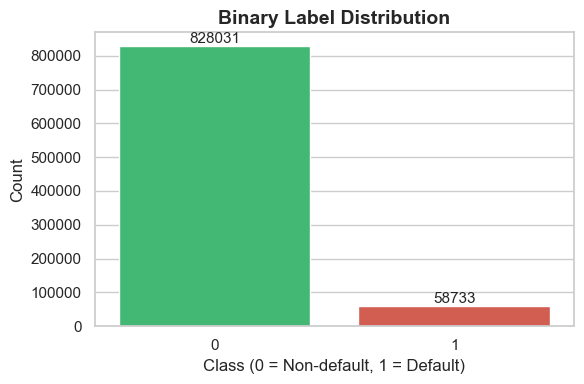

Near-constant columns removed (>= 0.9995): 6


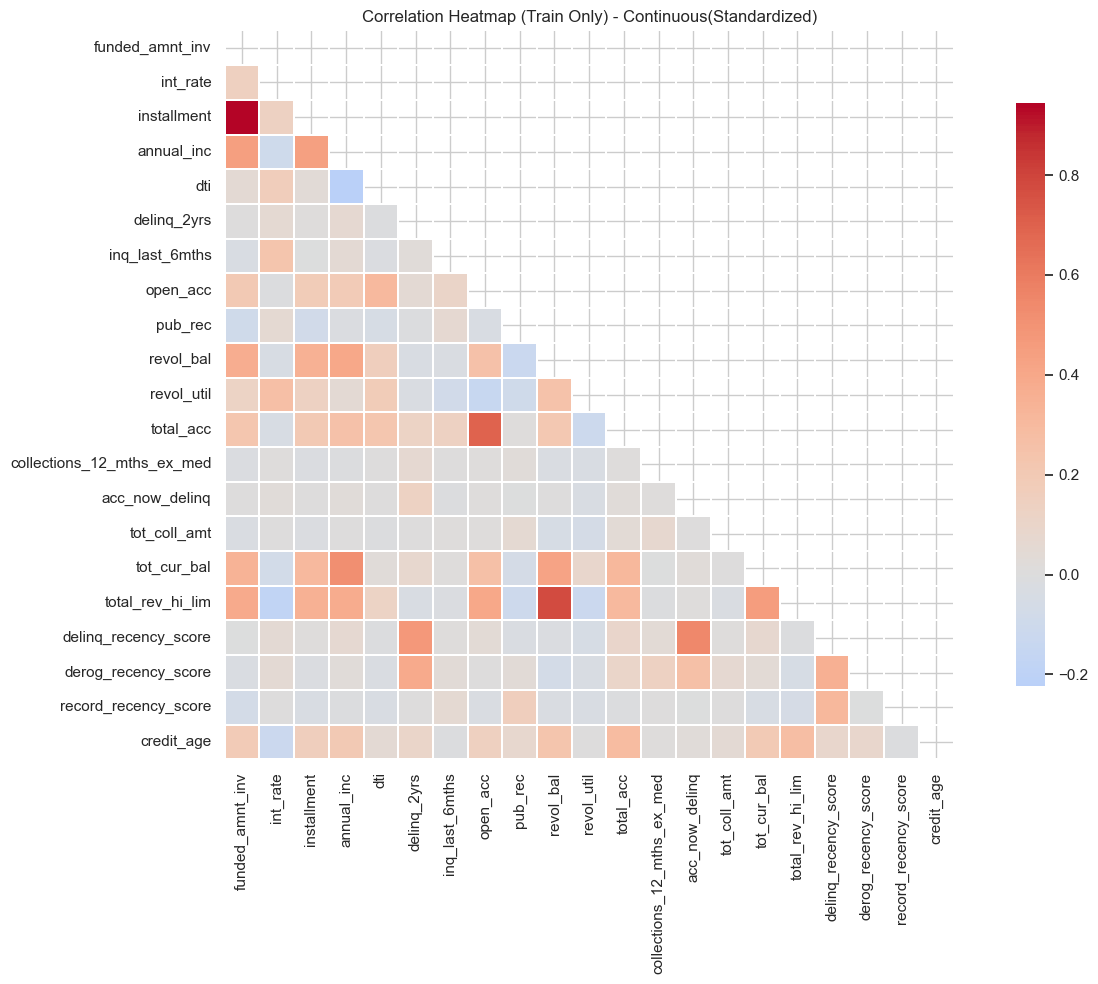

High-correlation pairs (|corr| >= 0.75):
funded_amnt_inv              installment               0.943730
pub_rec                      ever_public_record        0.857282
ever_major_derog             derog_60m                 0.823777
revol_bal                    total_rev_hi_lim          0.778728
home_ownership_MORTGAGE      home_ownership_RENT      -0.818832
application_type_INDIVIDUAL  application_type_JOINT   -1.000000
initial_list_status_f        initial_list_status_w    -1.000000
dtype: float64

ORIGINAL X_train.columns:
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'purpose', 'initial_list_status', 'issue_d', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'addr_state', 'application_type', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_

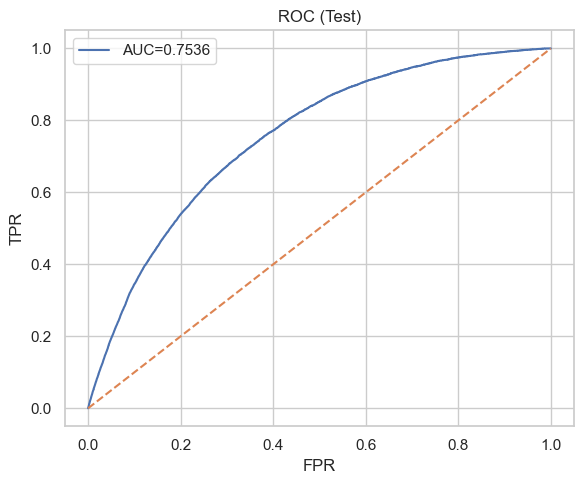

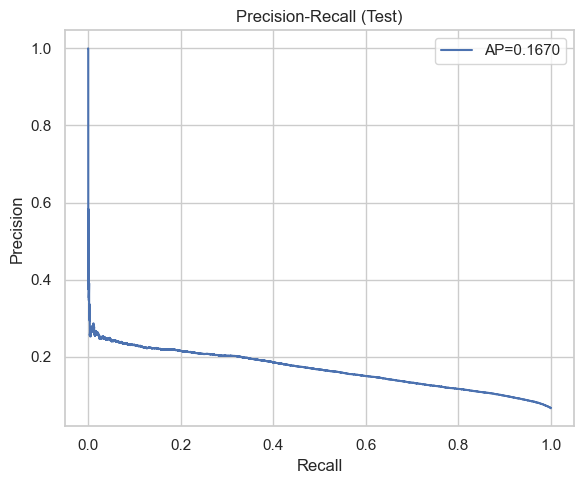

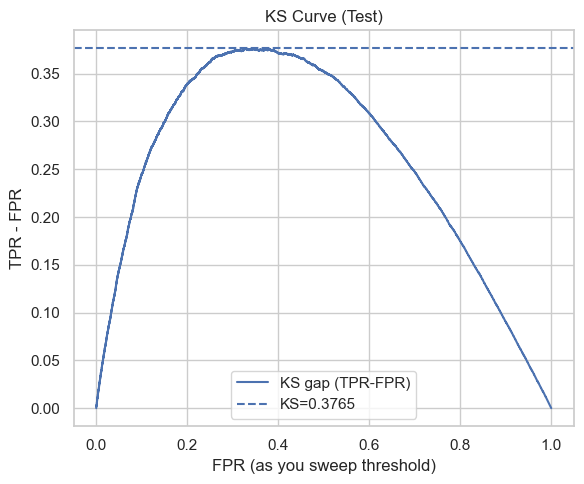


Decile / Lift (TEST) | base_bad_rate=0.066235 | higher bin=lower risk? Here bin=1 is the highest risk(highest p)
   bin      n  bads  bad_rate    p_mean      lift   cum_n  cum_bads  cum_bad_rate  cum_capture
0    1  17736  3591  0.202470  0.213372  3.056830   17736      3591      0.202470     0.305695
1    2  17735  2307  0.130082  0.121195  1.963939   35471      5898      0.166277     0.502086
2    3  17735  1674  0.094390  0.086128  1.425069   53206      7572      0.142315     0.644590
3    4  17735  1237  0.069749  0.066136  1.053053   70941      8809      0.124174     0.749894
4    5  17736  1002  0.056495  0.052163  0.852950   88677      9811      0.110637     0.835192
5    6  17735   736  0.041500  0.041337  0.626554  106412     10547      0.099115     0.897846
6    7  17735   507  0.028588  0.032259  0.431607  124147     11054      0.089040     0.941006
7    8  17735   369  0.020806  0.024530  0.314128  141882     11423      0.080511     0.972418
8    9  17735   202  0.011390  

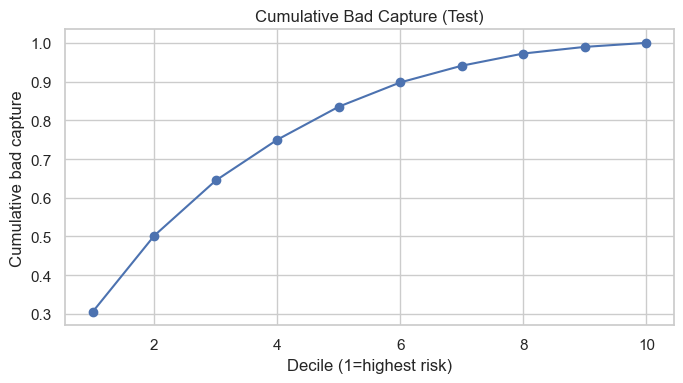

In [ ]:
def main():
    X_raw, y_bin = load_and_engineer_features("loan.csv")
    plot_label_distribution(y_bin)

    X_train, X_val, X_test, yb_train, yb_val, yb_test = split_data(X_raw, y_bin)

    X_train, X_val, X_test = preprocess_splits(X_train, X_val, X_test)

    count01(yb_train, "yb_train")
    count01(yb_val, "yb_val")
    count01(yb_test, "yb_test")

    _ = run_logistic_regression_module(X_train, X_val, X_test, yb_train, yb_val, yb_test)
if __name__ == "__main__":
    main()